In [ ]:
pip install pandas

In [ ]:
pip install matplotlib

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Jagdish singh\OneDrive\Desktop\mongo\analytics project dataset churn\churn analysis\Customer Churn.csv"
)

df.head()


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
df["customerID"].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: customerID, Length: 7043, dtype: bool

In [25]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)

In [ ]:
df.head()

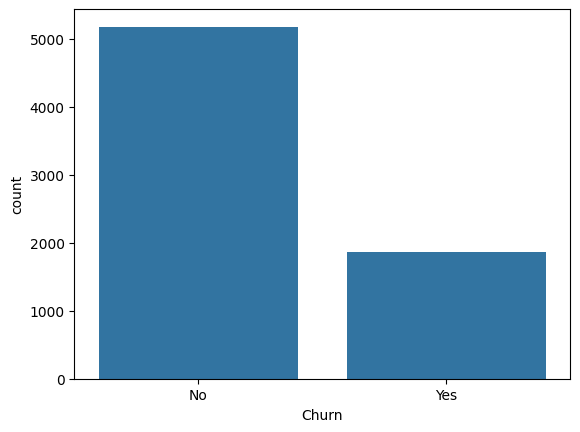

In [28]:
sns.countplot(x=df['Churn'], data =df)
plt.show()

In [39]:
df.groupby("Churn").size()


Churn
No     5174
Yes    1869
dtype: int64

In [36]:
gb=df.groupby("Churn").agg({"Churn" :"count"})
gb

,Churn
Churn,
No,5174
Yes,1869


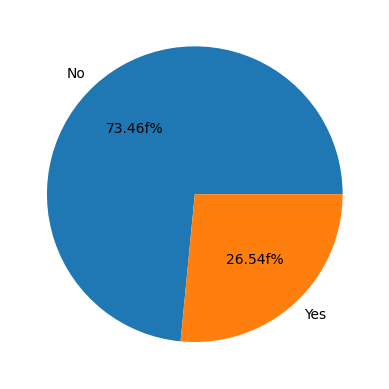

In [40]:

plt.pie(gb['Churn'],labels=gb.index,autopct="%1.2ff%%")
plt.show()

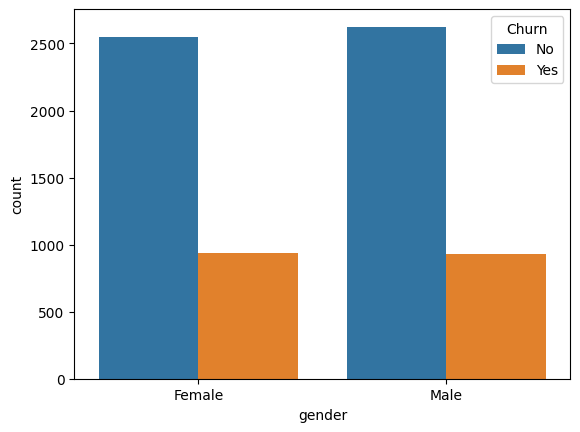

In [46]:
sns.countplot(x=df["gender"], data=df , hue="Churn")
plt.show()

In [48]:
sr=df.groupby("SeniorCitizen").size()
sr

SeniorCitizen
no     5901
yes    1142
dtype: int64

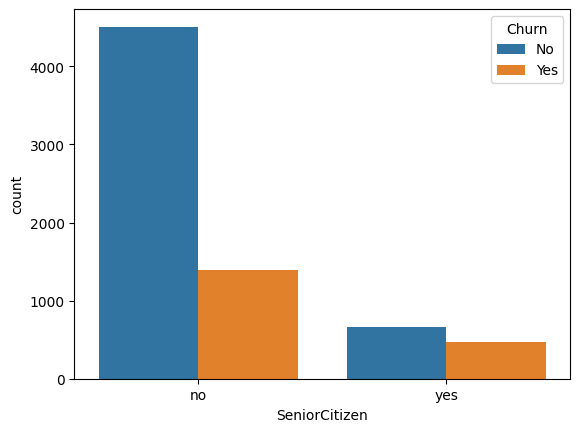

In [51]:
sns.countplot(x= df["SeniorCitizen"] , data=df , hue="Churn")
plt.show()

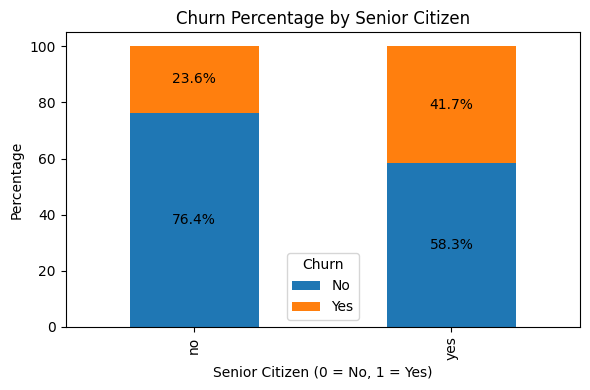

In [52]:
percent_table = (
    pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
)

# Plot stacked bar chart
ax = percent_table.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

# Labels & title
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Percentage")
plt.title("Churn Percentage by Senior Citizen")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [ ]:
# grater eprctage of senior citizen has churend out arounf 59 %

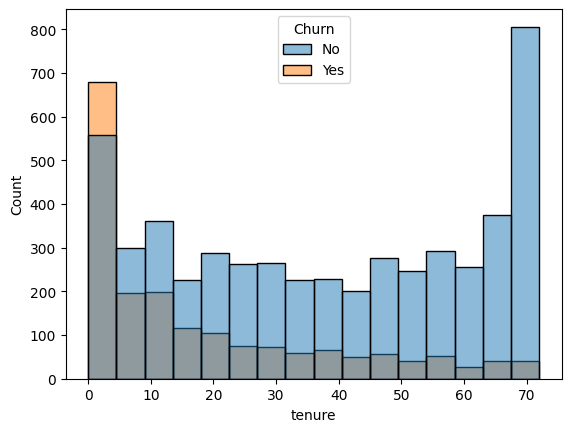

In [55]:
sns.histplot(x="tenure", data=df , hue="Churn")
plt.show()

In [ ]:
#people who have used services for 1 ,2 months have churened out 

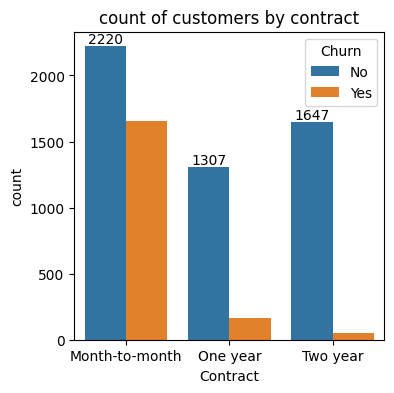

In [58]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x="Contract", data=df , hue ="Churn")
ax.bar_label(ax.containers[0])
plt.title("count of customers by contract")
plt.show()

In [ ]:
# people who have month to month are likley to churn then from those who have 1 or 2 years of contract

In [60]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'seniorCitizen'],
      dtype='object')

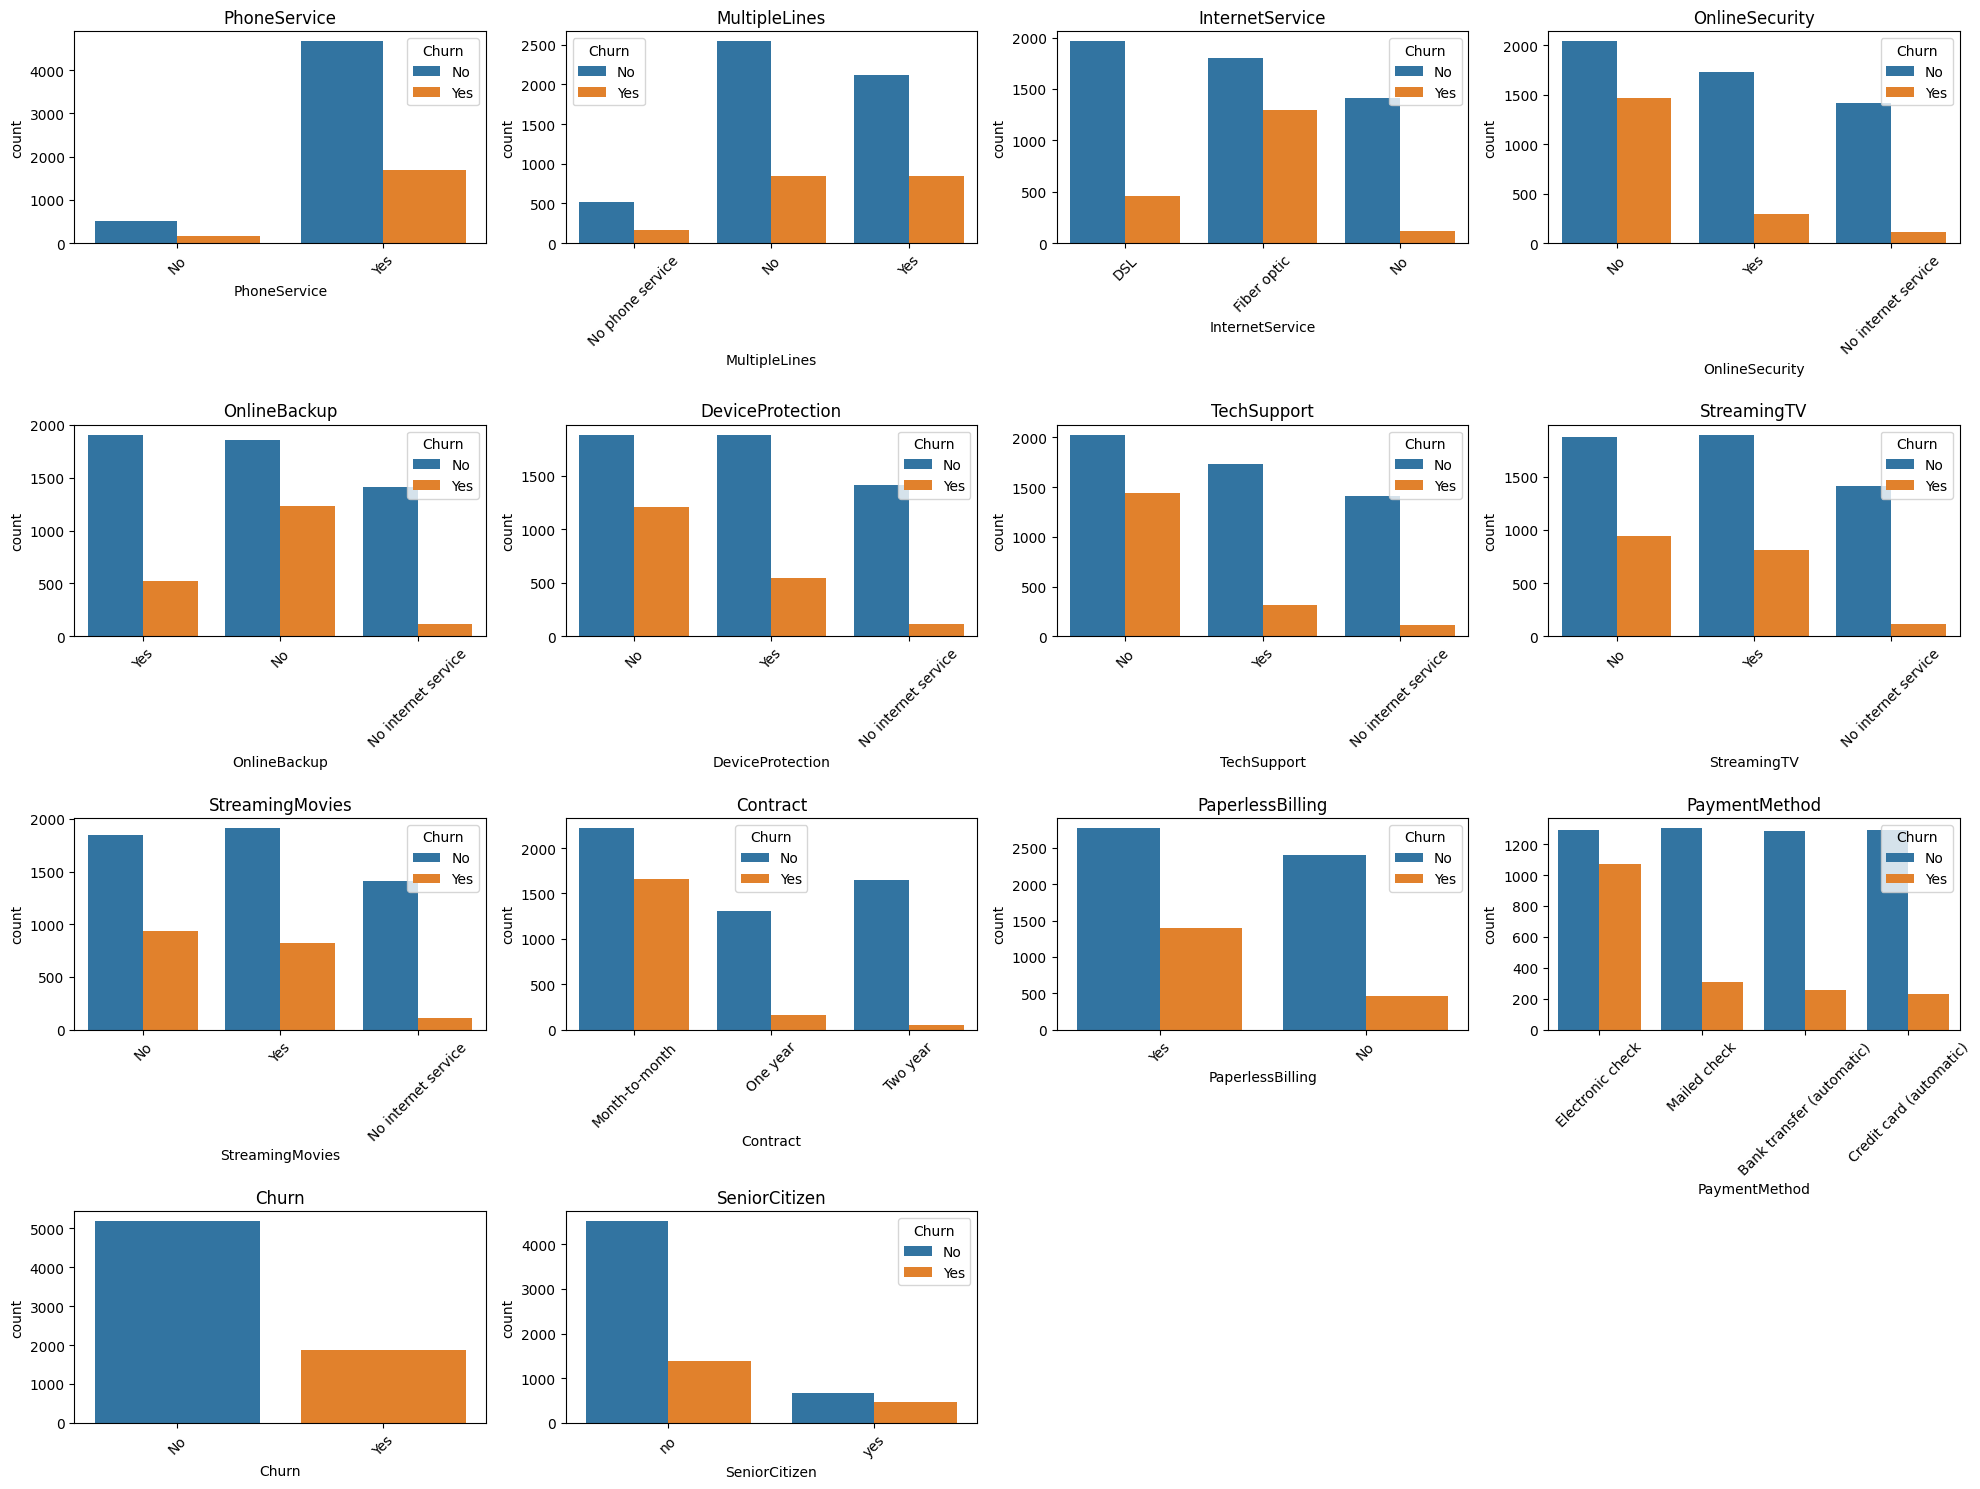

In [63]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'Churn', 'SeniorCitizen'
]

# Set subplot grid size
rows = 4
cols_grid = 4

fig, axes = plt.subplots(rows, cols_grid, figsize=(20, 15))
axes = axes.flatten()

# Plot countplots
for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i] , hue ="Churn")
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Summary (from the subplots):

The countplots show how each service feature and customer attribute is distributed and how it relates to Churn (Yes/No).

Customers with month-to-month contracts, no online security/tech support, and paperless billing exhibit a visibly higher churn proportion.

Senior citizens and customers using fiber optic internet tend to churn more compared to their counterparts.

Overall, customers with longer contracts and added services show lower churn, indicating stronger retention.

In [ ]:
# we can paste graph and get summary of the results of graph

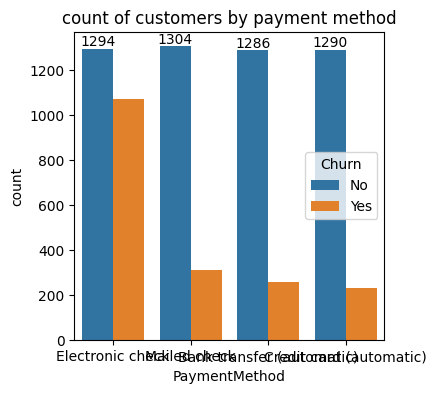

In [64]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x="PaymentMethod", data=df , hue ="Churn")
ax.bar_label(ax.containers[0])
plt.title("count of customers by payment method")
plt.show()

In [ ]:
#Customers using Electronic Check show the highest churn, indicating it is the riskiest payment method.

Automatic payment methods (Credit Card automatic, Bank Transfer automatic) have significantly lower churn, suggesting better customer retention.

Mailed checks fall in between, with moderate churn compared to electronic checks.

Overall, customers enrolled in automatic payments are more stable and less likely to churn.